<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/04wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-zbDLzYRNIBV16xs5i6AtGW&si=XQvYuwih7pcYqbah>}}

# 2. Imports

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. 기호

## A. 기호를 중시하는 사람

`-` 기호만이 우리를 구원할 수 있다.



`-` 다른 의미를 가진다면, 다른 기호를 써야함.

`-` 하지만 현실은 그렇지 않음.

- $x^2+2x+1=0$ 에서 $x$가 의미하는 기호와
- $f(x)=x^2+2x+1$ 에서 $x$가 의미하는 기호는 같은가?

`-` 되게 미묘한 차이 -- 아래의 식에서 $x$는 모두 같은 의미를 가지진 않음.

`# 고등학교 문제` -- $f(x)=(x-2)^2$의 최소값을 구하자.

(sol)

$f(x)=(x-2)^2$ 이고 $f''(x)=2>0$ 이다. 따라서 $f'(x)=2(x-2)=0$ 을 만족하는 $x$가 답이다. 따라서 $x=2$.

`#`

## B. 회귀분석 교재의 전설

`-` ref: *Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). Introduction to linear regression analysis. John Wiley & Sons.*

`-` 역시 전설??

## C. 저의 감각

`-` 보통 함수에서의 변수 $x$와 미지수 $x$는 구분하지 않고 쓰더라..

`-` $x$가 어떠한 고정된 값임을 강조하고 싶을때 $x_0,x^\ast$ 를 쓰는 경우가 많다. $f(x_0)$ 이런 느낌으로..

`-` $x$가 어떠한 함수를 최소화 혹은 최대화하는 값을 의미할때는 $x^\ast, x^\star$ 을 많이 쓰는 것 같다.

`-` 통계학에서 어떠한 값이 estimated/predicted/fitted 를 의미할 경우 hat을 많이 사용한다. 예를들어 $\hat{\beta}_0, \hat{y}_i$.

> 구분할수 있으면 엄밀하게 구분하는게 좋지만, 때로는 그냥 적당히 넘어가는 것도 필요하다.

# 4. 파이토치를 이용한 미분

`# 예제1` -- 파이썬 기본문법을 이용한 미분

In [3]:
def f(x):
    return x**2

In [4]:
x0 = 8
h = 0.0001
(f(x0+h)-f(x0))/h

16.00009999989993

`#`

`# 예제2` -- `torch`를 이용한 미분

In [5]:
def f(x):
    return x**2
x0 = torch.tensor(8.0, requires_grad = True)
y0 = f(x0)
y0.backward()
x0.grad

tensor(16.)

In [6]:
def f(x):
    return x**2
x = torch.tensor(8.0, requires_grad = True)
y = f(x)
y.backward()
x.grad

tensor(16.)

`# 예제3` -- 예제2를 좀 더 자세히

In [7]:
x = torch.tensor(8.0, requires_grad = True)
x # 토치텐서, 꼬리표가 붙은...

tensor(8., requires_grad=True)

In [8]:
x.data, x.grad # x.data에는 꼬리표없는 순수텐서있음, x.grad는 비어있음

(tensor(8.), None)

In [9]:
y = f(x) # y는 x에서 발생한 꼬리표가 남아있음.
y

tensor(64., grad_fn=<PowBackward0>)

In [10]:
y.backward() # y를 미분하라. 뭐로?? y에 미분꼬리표를 생기게 한 근원 x로 미분하라. (미분결과는 x.grad에 저장함)

In [11]:
x.data, x.grad

(tensor(8.), tensor(16.))

`#`

`# 예제4` -- 복잡해보이는 다른예제

In [12]:
x = torch.tensor(3.0, requires_grad = True)
x

tensor(3., requires_grad=True)

In [13]:
y = f(x)
y

tensor(9., grad_fn=<PowBackward0>)

In [14]:
z = 2*y # z = 2*f(x) = 2x^2
z

tensor(18., grad_fn=<MulBackward0>)

In [15]:
z.backward() # z를미분하라. 뭘로미분하냐? z에 생긴 미분꼬리표의 근원이 되는 x로 미분하라.

In [16]:
x.data, x.grad # z= 2x^2 --> z' = 4x

(tensor(3.), tensor(12.))

`#`

`# 예제5`

예제4를 다시 정리하면

In [17]:
x = torch.tensor(4.0, requires_grad = True)
y = f(x)
z = 2*y
z.backward()
x.data, x.grad

(tensor(4.), tensor(16.))

그런데 굳이 $f(x)$를 명시하지 않아도 잘 동작함.

In [18]:
x = torch.tensor(4.0, requires_grad = True)
y = x**2
z = 2*y
z.backward()
x.data, x.grad

(tensor(4.), tensor(16.))

`#`

`# 예제6` -- 다변수

$f(x_1,x_2) = (x_1+2x_2)^2$ 를 고려하자. $\frac{\partial}{\partial x_1}f(x_1,x_2) \Big|_{x_1=2.5,x_2=2.5}$, $\frac{\partial}{\partial x_2}f(x_1,x_2) \Big|_{x_1=2.5,x_2=2.5}$를 계산하라.

(지난시간방식)

In [19]:
def f(x1,x2):
    return (x1+2*x2)**2
x1 = 2.5
x2 = 2.5

In [20]:
(f(x1+0.001,x2)-f(x1,x2))/0.001,  (f(x1,x2+0.001)-f(x1,x2))/0.001

(15.000999999990938, 30.003999999998143)

(파이토치이용)

In [21]:
x1 = torch.tensor(2.5,requires_grad = True)
x2 = torch.tensor(2.5,requires_grad = True)
y = f(x1,x2)
y.backward() # y를 미분하라. 뭐로? 꼬리표가 생기게한 x1,x2 로!

In [22]:
x1.grad, x2.grad

(tensor(15.), tensor(30.))

(벡터+파이토치이용)

In [23]:
x = torch.tensor([[2.5],[2.5]],requires_grad=True)
y = (torch.tensor([[1.0, 2.0]]) @ x)**2
y.backward()
x.grad

tensor([[15.],
        [30.]])

`# 예제7` --

$f(x) = x^2$ 일때 $f'(2)$와 $f'(3)$을 파이토치를 이용하여 구하라.

(첫번째 풀이)

In [24]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2
y.backward()
x.data, x.grad

(tensor(2.), tensor(4.))

In [25]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
x.data, x.grad

(tensor(3.), tensor(6.))

(잘못된풀이)

In [26]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [27]:
y = x**2
y.backward()

In [28]:
x.data, x.grad

(tensor(2.), tensor(4.))

In [29]:
x.data = torch.tensor(3.0)
x.data, x.grad

(tensor(3.), tensor(4.))

In [30]:
y = x**2
y.backward()
x.data, x.grad

(tensor(3.), tensor(10.))

- 왜 `x.grad=10` 일까? $f'(2)+f'(3)=4+6=10$

`(잘못을 수정한 풀이)` -- 이게 첫번째 풀이보다 더 좋음.. 왜?? 메모리효율 (깊게알필요X)

In [31]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [32]:
y = x**2
y.backward()

In [33]:
x.data, x.grad

(tensor(2.), tensor(4.))

In [34]:
x.data = torch.tensor(3.0)
x.grad = None
x.data, x.grad

(tensor(3.), None)

In [35]:
y = x**2
y.backward()
x.data, x.grad

(tensor(3.), tensor(6.))

# 5. 회귀분석

## A. 문제

`-` 모형

$$y_i = w_0^\ast + w_1^\ast x_i + \epsilon_i$$

In [36]:
torch.manual_seed(43052)
x = torch.randn(100).sort()[0]
eps = torch.randn(100)*0.5
w0ast = 2.5
w1ast = 4
y = w0ast + w1ast*x + eps

`-` 시각화

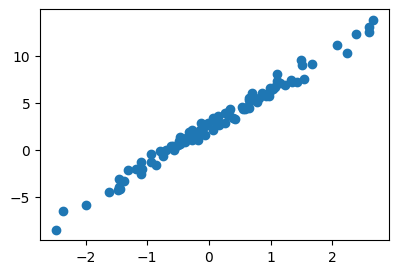

In [37]:
plt.plot(x,y,'o')
#plt.plot(x,w0ast + w1ast*x,'--')

## B. 풀이1 -- 지난시간

(엄밀하게)

In [38]:
def l(w0,w1):
    return torch.sum((y - (w0 + w1*x))**2)

In [39]:
w0tilde = -5
w1tilde = 10

In [40]:
for epoch in range(30):
    w0tilde_grad = (l(w0tilde + 0.001, w1tilde)- l(w0tilde, w1tilde))/0.001
    w1tilde_grad = (l(w0tilde, w1tilde+0.001)- l(w0tilde, w1tilde))/0.001
    w0tilde = w0tilde - 0.001 * w0tilde_grad
    w1tilde = w1tilde - 0.001 * w1tilde_grad

In [41]:
w0hat = w0tilde
w1hat = w1tilde

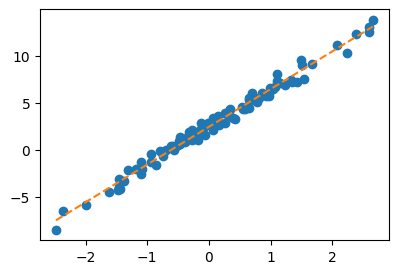

In [42]:
plt.plot(x,y,'o')
plt.plot(x,w0hat+w1hat*x,'--')

(대충)

In [43]:
def l(w0,w1):
    return torch.sum((y - (w0 + w1*x))**2)

In [44]:
w0hat = -5
w1hat = 10

In [45]:
for epoch in range(30):
    w0hat_grad = (l(w0hat + 0.001, w1hat)- l(w0hat, w1hat))/0.001
    w1hat_grad = (l(w0hat, w1hat+0.001)- l(w0hat, w1hat))/0.001
    w0hat = w0hat - 0.001 * w0hat_grad
    w1hat = w1hat - 0.001 * w1hat_grad

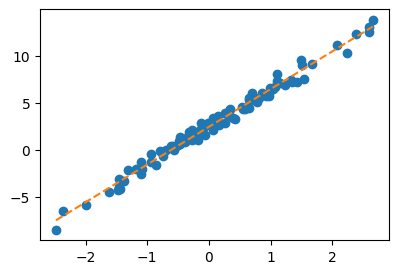

In [46]:
plt.plot(x,y,'o')
plt.plot(x,w0hat+w1hat*x,'--')

## C. 풀이2 -- 파이토치 사용

In [47]:
w0hat = torch.tensor(-5.00, requires_grad=True)
w1hat = torch.tensor(10.00, requires_grad=True)

In [48]:
for epoch in range(30):
    yhat = w0hat + w1hat*x # y의 predicted value, 혹은 fitted value라고 볼수있음.
    loss = torch.sum((y - yhat)**2)
    loss.backward()
    w0hat.data = w0hat.data - 0.001 * w0hat.grad
    w1hat.data = w1hat.data - 0.001 * w1hat.grad
    w0hat.grad = None
    w1hat.grad = None

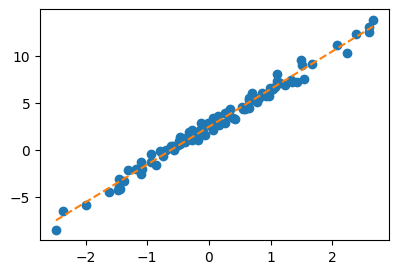

In [49]:
plt.plot(x,y,'o')
plt.plot(x,w0hat.data + w1hat.data*x,'--')

In [50]:
w0hat,w1hat

(tensor(2.4290, requires_grad=True), tensor(4.0144, requires_grad=True))

## D. 풀이3 -- matrix ver

`-` 아이디어: 아래의 모형

$$y_i = w_0^\ast + w_1^\ast x_i + \epsilon_i$$

을 아래와 같이 matrix로 해석하자.

$$\begin{bmatrix}
y_1 \\ y_2 \\ \dots \\ y_n \end{bmatrix} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \dots \\ 1 & x_n \end{bmatrix}\begin{bmatrix} w_0^\ast \\ w_1^\ast \end{bmatrix} +\begin{bmatrix}
\epsilon_1 \\ \epsilon_2 \\ \dots \\ \epsilon_n \end{bmatrix} $$

`-` 최초의 주황색점선은

In [51]:
w0hat = torch.tensor(-5.00, requires_grad=True)
w1hat = torch.tensor(10.00, requires_grad=True)
yhat = w0hat + w1hat * x
yhat[:5]

tensor([-29.8211, -28.6215, -24.9730, -21.2394, -19.7919],
       grad_fn=<SliceBackward0>)

In [52]:
yhat.shape

torch.Size([100])

이런식으로 구했었는데, 이제는 아래와 같이 구할 수 있다.

In [53]:
X = torch.stack([torch.ones(100), x],axis=1)
What = torch.tensor([[-5.00],[10.00]],requires_grad=True)
Yhat= X@What
Yhat[:5]

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919]], grad_fn=<SliceBackward0>)

In [54]:
What.shape

torch.Size([2, 1])

`-` 첫 미분값은 원래 아래와 같이 구했는데..

In [55]:
w0hat = torch.tensor(-5.00, requires_grad=True)
w1hat = torch.tensor(10.00, requires_grad=True)
#---#
yhat = w0hat + w1hat * x
loss = torch.sum((y-yhat)**2)
loss.backward()
w0hat.grad, w1hat.grad

(tensor(-1342.2524), tensor(1188.9305))

이제는 아래와 같이 하면된다.

In [56]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
What = torch.tensor([[-5.00],[10.00]],requires_grad=True)
#---#
Yhat = X@What
loss = torch.sum((Y-Yhat)**2)
loss.backward()
What.data, What.grad

(tensor([[-5.],
         [10.]]),
 tensor([[-1342.2524],
         [ 1188.9305]]))

`-` 업데이트는 원래 아래와 같이 했었는데

In [57]:
w0hat.data = w0hat.data - 0.001 * w0hat.grad
w1hat.data = w1hat.data - 0.001 * w1hat.grad
w0hat,w1hat

(tensor(-3.6577, requires_grad=True), tensor(8.8111, requires_grad=True))

In [58]:
What.data = What.data - 0.001 * What.grad
What

tensor([[-3.6577],
        [ 8.8111]], requires_grad=True)

`-` 그래서 새로운 코드를 정리하면

In [59]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
What = torch.tensor([[-5.00],[10.00]],requires_grad=True)
#---#
for epoch in range(30):
    Yhat = X@What
    loss = torch.sum((Y-Yhat)**2)
    loss.backward()
    What.data = What.data - 0.001 * What.grad
    What.grad = None

In [60]:
What.data

tensor([[2.4290],
        [4.0144]])

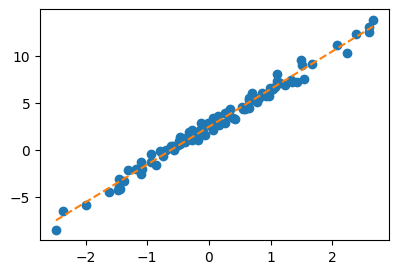

In [61]:
plt.plot(x,y,'o')
# plt.plot(x,(X@What).reshape(-1).data,'--')
plt.plot(x,(X@What).reshape(-1).detach(),'--')

## E. 풀이4 -- MSE

In [62]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
What = torch.tensor([[-5.00],[10.00]],requires_grad=True)
#---#
for epoch in range(30):
    Yhat = X@What
    loss= torch.mean((Y-Yhat)**2) # SSE를 MSE로 바꿈
    loss.backward()
    What.data = What.data - 0.1 * What.grad
    What.grad = None

In [63]:
What.data

tensor([[2.4290],
        [4.0144]])

## F. 풀이5 -- MSE

In [64]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
What = torch.tensor([[-5.00],[10.00]],requires_grad=True)
loss_fn = torch.nn.MSELoss()
#---#
for epoch in range(30):
    Yhat = X@What
    loss = loss_fn(Yhat,Y)
    loss.backward()
    What.data = What.data - 0.1 * What.grad
    What.grad = None

In [65]:
What.data

tensor([[2.4290],
        [4.0144]])

## G. 풀이6 -- `net`

`# net` -- net 오브젝트?

원래 `Yhat`을 이런식으로 구했는데..

```Python
Yhat = X @ What
```

그런데 `Yhat`을 아래와 같이 구할수 있도록 하고싶다.

```Python
Yhat = net(X)
```

위와 같은 코드를 가능하게 하는 `net`은 파이토치에서 공식지원하고, 아래와 같이 같이 사용할 수 있음.

In [66]:
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
# net(X)

`net(X)`는 사실 아래의 동작과 동일하다.

In [67]:
# X @ net.weight.T

여기에서 `net.weight.T`의 값은 net가 생성될때마다 랜덤하게 바귄다. 우리가 `What`의 초기값을 $\begin{bmatrix} -10 \\ 5 \end{bmatrix}$로 설정하였듯이 `net.weight.T`의 초기값도 바꾸고싶다면 아래와 같이 강제설정할 수 있다.

In [68]:
net.weight.data = torch.tensor([[-10.0,5.0]])

그러면 이제 아래의 두 코드는 같은 효과를 가진다.

In [69]:
net(X)[:3]

tensor([[-22.4106],
        [-21.8107],
        [-19.9865]], grad_fn=<SliceBackward0>)

In [70]:
What = torch.tensor([[-10.0],[5.0]])
(X @ What)[:3]

tensor([[-22.4106],
        [-21.8107],
        [-19.9865]])

`-` 정리를 하면 아래와 같다.

In [71]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
net.weight.data = torch.tensor([[-5.00,10.00]])
loss_fn = torch.nn.MSELoss()
#---#
for epoch in range(30):
    Yhat = net(X)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    net.weight.data = net.weight.data - 0.1 * net.weight.grad
    net.weight.grad = None

In [72]:
net.weight

Parameter containing:
tensor([[2.4290, 4.0144]], requires_grad=True)

## H. 풀이7 -- `optimizer`

In [83]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
net.weight.data = torch.tensor([[-5.00,10.00]])
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(),lr=0.1)
#---#
for epoch in range(30):
    Yhat = net(X)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    optimizer.step() # 업데이트해~
    net.weight.grad = None

In [84]:
net.weight

Parameter containing:
tensor([[2.4290, 4.0144]], requires_grad=True)

## I. 풀이8 -- `optimizer`, `zero_grad`

In [87]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = False
)
net.weight.data = torch.tensor([[-5.00,10.00]])
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(),lr=0.1)
#---#
for epoch in range(30):
    Yhat = net(X)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [88]:
net.weight

Parameter containing:
tensor([[2.4290, 4.0144]], requires_grad=True)

## J. 풀이9 -- `net`, `bias`

`-` `net`에서 `bias=False`가 의미하는건 뭘까?

`-` 간단함

```Python
# 이렇게 선언하면
net = torch.nn.Linear(..., bias=False)
# 아래의 두 코드는 같은효과
net(inp)
inp @ net.weight.T
```

```Python
# 이렇게 선언하면
net = torch.nn.Linear(..., bias=True)
# 아래의 두 코드는 같은효과
net(inp)
inp @ net.weight.T + net.bias
```

`-` 아래의 코드도 돌아가긴 하지만 조금 비효율적임

In [105]:
Y = y.reshape(-1,1)
X = torch.stack([torch.ones(100), x],axis=1)
net = torch.nn.Linear(
    in_features=2,
    out_features=1,
    bias = True
)
net.weight.data = torch.tensor([[-5.00,10.00]])
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(),lr=0.1)
#---#
for epoch in range(30):
    Yhat = net(X)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

`-` 결과해석

In [125]:
net.weight, net.bias

(Parameter containing:
 tensor([[-1.0241,  4.0080]], requires_grad=True),
 Parameter containing:
 tensor([3.4689], requires_grad=True))

In [126]:
-1.0242 + 3.4689 # 이게 w0hat의 효과

2.4447

In [128]:
4.0080 # 이게 w1hat

4.008

`-` 아래와 같이 코드를 짜면 풀이2-8까지 했던것과 정확하게 같은 코드가 된다.

In [174]:
Y = y.reshape(-1,1)
X1 = x.reshape(-1,1)
net = torch.nn.Linear(
    in_features=1,
    out_features=1,
    bias = True
)
net.weight.data = torch.tensor([[10.00]]) # w1hat의 역할
net.bias.data = torch.tensor([-5.0]) # w0hat의 역할
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(net.parameters(),lr=0.1)
#---#
for epoch in range(30):
    Yhat = net(X1)
    loss = loss_fn(Yhat,Y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [175]:
net.weight, net.bias

(Parameter containing:
 tensor([[4.0144]], requires_grad=True),
 Parameter containing:
 tensor([2.4290], requires_grad=True))

## K. 풀이10

`-` 통계학과만 아는 풀이

In [161]:
torch.linalg.inv(X.T @ X) @ X.T @ Y # 이게 What

tensor([[2.4459],
        [4.0043]])

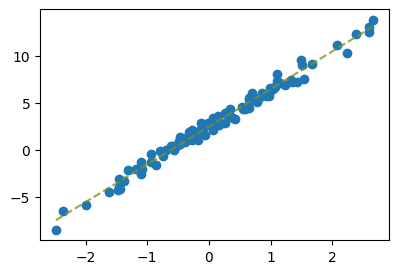

In [167]:
plt.plot(x,y,'o')
plt.plot(x,2.4459 + 4.0043*x,'--',alpha=0.5) # 회귀분석에서 배운대로 구한값
plt.plot(x,2.4290 + 4.0144*x,'--',alpha=0.5) # 딥러닝시간에 배운 새로운 테크닉 경사하강법을 이용한 결과

In [170]:
l(2.4459,4.0043) # 회귀분석에서 배운대로 구했을 경우 loss

tensor(26.3600)

In [171]:
l(2.4290,4.0144) # 딥러닝에서 배운대로 구했을 경우 loss

tensor(26.3958)

`-` 딥러닝에서 배운 방법은 계산량도 많고 부정확하지만, 미분을 직접손으로 구하지 않아도 된다는 장점이 있다. (벡터미분 몰라도 된다.) 회귀문제의 경우 적절한 학습률을 선택하고 많은 반복을 하면 결국 딥러닝에서 배운 경사하강법은 회귀분석에서 배운 해석해로 수렴한다.

`-` 문제: 경사하강법으로 회귀문제를 푼다고 하자. 반복이 많으면 (epoch이 크면) 결국 $\hat{\bf W}$은 $\begin{bmatrix} 2.5 \\  4\end{bmatrix}$ 으로 가는가?

- 답변: 절대 못찾아감. 회귀분석에서 배운 해석해를 찾아간다.



`-` 그러면 $\begin{bmatrix} 2.5 \\  4\end{bmatrix}$ 에 점점 가깝게 추정하기 위해서는 어떻게 해야하나?? 데이터를 더 모아야함. (즉 현재 $n=100$인데 이것이 $n=1000, 10000$ 이런식으로 커지면 추정값이 점점 true에 가까워짐)
